# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import summary_table
import scipy.stats
from matplotlib.ticker import AutoMinorLocator
from matplotlib.lines import Line2D
from mycolorpy import colorlist as mcp
from matplotlib_scalebar.scalebar import ScaleBar
import geopandas as gpd
import rioxarray as rx
import xarray as xr
from pysal.lib import weights
import shapely.geometry
import os
from datetime import datetime
import pyproj

proj_dir = pyproj.datadir.get_data_dir()
os.environ["PROJ_LIB"] = proj_dir
os.environ["PROJ_DATA"] = proj_dir

print("Using PROJ data from:", proj_dir)

Using PROJ data from: /your/path/to/conda/envs/geo-env/lib/python3.10/site-packages/pyproj/proj_dir/share/proj


# Define country and parameters

In [2]:
# Select target country
country = 'Colombia'

# Set country-specific parameters: ISO codes and buffer size (in meters)
if country == 'Argentina':
    country_short = 'ARG'   # ISO 3-letter code
    country_code = 'AR'     # ISO 2-letter code
elif country == 'Chile':
    country_short = 'CHL'
    country_code = 'CL'
elif country == 'Colombia':
    country_short = 'COL'
    country_code = 'CO'
# Uncomment the following if Mexico is to be included in the analysis
# elif country == 'Mexico':
#     country_short = 'MEX'
#     country_code = 'MX'

# Set working directory

In [3]:
# Define working directory path
wd = (
    '/your/path/to/working/directory/'
)


# Merge Facebook Population grid with baseline population data 
and quick plot to see where missing values are

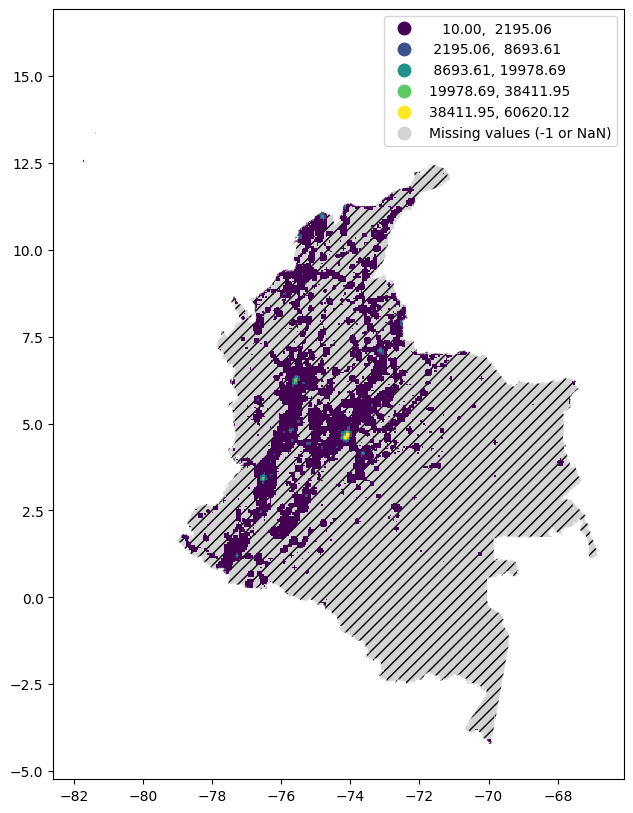

In [4]:
# Load grid shapefile and convert to EPSG:4326 coordinate reference system
grid_pop = gpd.read_file(
    wd + f'/data/inputs/grids/Grid_{country}_FB_pop/Grid_{country}.shp'
).to_crs('EPSG:4326')

# Load baseline population data
baseline_pop = pd.read_csv(wd + f'/data/outputs/{country_short}/baseline/baseline_pop.csv')

# Replace missing and placeholder values
baseline_pop = baseline_pop.fillna(-1)
baseline_pop = baseline_pop.replace(-999, -1)

# Merge spatial grid with baseline population data using 'FID' as key
grid_pop = pd.merge(grid_pop, baseline_pop, on='FID', how='left')


# Quick plot of baseline population values for Monday (column '0') 
# using Natural Breaks classification with 5 bins.
# Missing values (-1) are treated as NaN for plotting only, without modifying the original dataframe.

# Create a temporary column for plotting where -1 is replaced by NaN to mark missing values
plot_col = grid_pop['0'].replace(-1, np.nan)

# Plot using the temporary column; the original grid_pop remains unchanged
grid_pop.assign(plot_col=plot_col).plot(
    column='plot_col',
    legend=True,
    scheme="NaturalBreaks",
    k=5,
    figsize=(15, 10),
    missing_kwds={
        "color": "lightgrey",
        "hatch": "///",
        "label": "Missing values (-1 or NaN)",
    },
)

plt.show()


# Integrate WorldPop raster data with FB population grid 
...and handle anomalies for Mexico

In [5]:
# This cell:
# - Loads WorldPop raster and converts to GeoDataFrame of points with population values
# - Spatially joins population points to FB grid cells and aggregates population per cell
# - For Mexico, smooths max population value (a WorldPop outlier) using spatial lag of neighbours

# Load the WorldPop raster file for the specified country (1km resolution)
rds = rx.open_rasterio(
    wd + f'/data/inputs/population/worldpop/{country_short.lower()}_ppp_2020_1km_Aggregated.tif'
)
rds.name = "population"

# Convert the raster to a DataFrame, with one row per pixel
df = rds.squeeze().to_dataframe().reset_index()

# Create point geometries from the pixel centroid coordinates
geometry = gpd.points_from_xy(df.x, df.y)

# Convert the DataFrame to a GeoDataFrame with the appropriate CRS and geometry column
gdf_worldpop = gpd.GeoDataFrame(df, crs=rds.rio.crs, geometry=geometry)

# Drop columns no longer needed: 'x', 'y', 'band', and 'spatial_ref'
gdf_worldpop = gdf_worldpop.drop(['x', 'y', 'band', 'spatial_ref'], axis=1)

# Remove rows where population value is undefined (coded as -99999)
gdf_worldpop = gdf_worldpop[gdf_worldpop['population'] != -99999].reset_index(drop=True)

# Reproject GeoDataFrame to WGS84 geographic coordinates (EPSG:4326)
gdf_worldpop = gdf_worldpop.to_crs('EPSG:4326')

# Spatial join of grid cells with WorldPop points
# Note: This operation drops grid cells without matching raster pixels, which may be addressed later
grid_wp = gpd.sjoin(grid_pop, gdf_worldpop)

# Aggregate joined data by grid cell (FID) summing population and other numeric columns
grid_wp_group = grid_wp.drop(['geometry', 'index_right'] + [str(i) for i in range(7)], axis=1)
grid_wp_group = grid_wp_group.groupby(['FID']).sum()

# Merge aggregated population data back to grid_wp to get one entry per grid cell with summed population
gdf_merge = pd.merge(grid_wp, grid_wp_group, on='FID')
gdf_merge = gdf_merge.drop(['index_right', 'population_x', 'geometry'] + [str(i) for i in range(7)], axis=1)
gdf_merge = gdf_merge.drop_duplicates().reset_index(drop=True)

# Merge the summarised population data into the original grid GeoDataFrame
gdf_mmerge = pd.merge(grid_pop, gdf_merge, how='left', on='FID')

# Rename population column for clarity and convert to GeoDataFrame
gdf_mmerge = gdf_mmerge.rename({'population_y': 'pop_wp'}, axis=1)
gdf_mmerge = gpd.GeoDataFrame(gdf_mmerge, geometry='geometry')

# Update the grid_pop variable with the merged data
grid_pop = gdf_mmerge

In [6]:
# Load built-up raster and derive a binary built-up flag for each FB population cell.
# We only need to know whether any built-up pixel is present, not the exact built-up area.
builtup_dir = os.path.join(wd, 'data', 'inputs', 'built-up')
builtup_candidates = []
for root, _, files in os.walk(builtup_dir):
    for fname in files:
        if fname.lower().endswith(('.tif', '.tiff')):
            builtup_candidates.append(os.path.join(root, fname))

if len(builtup_candidates) == 0:
    raise FileNotFoundError(f'No built-up raster found in {builtup_dir}')

preferred_candidates = [
    path for path in builtup_candidates
    if country_short.lower() in os.path.basename(path).lower() or country.lower() in os.path.basename(path).lower()
]
builtup_file = preferred_candidates[0] if len(preferred_candidates) > 0 else builtup_candidates[0]

rds_builtup = rx.open_rasterio(builtup_file, masked=True)
rds_builtup.name = 'builtup_surface'

In [7]:
# Convert to binary built-up presence and coarsen from 100 m to approximately 1 km.
# Then keep only positive built-up cells and do a single spatial join back to the FB grid.
rds_builtup = xr.where(rds_builtup > 0, 1, 0)
rds_builtup = rds_builtup.coarsen(x=10, y=10, boundary='trim').max().compute()


In [8]:
df_builtup = rds_builtup.squeeze().to_dataframe(name='has_builtup').reset_index()
drop_cols = [col for col in ['band', 'spatial_ref'] if col in df_builtup.columns]
if len(drop_cols) > 0:
    df_builtup = df_builtup.drop(columns=drop_cols)

In [9]:
df_builtup = df_builtup[df_builtup['has_builtup'] > 0].reset_index(drop=True)

In [10]:
if len(df_builtup) == 0:
    grid_pop['has_builtup'] = 0
else:
    gdf_builtup = gpd.GeoDataFrame(
        df_builtup,
        geometry=gpd.points_from_xy(df_builtup['x'], df_builtup['y']),
        crs=rds_builtup.rio.crs
    )
    gdf_builtup = gdf_builtup[['has_builtup', 'geometry']]
    grid_pop_raster_crs = grid_pop[['FID', 'geometry']].to_crs(rds_builtup.rio.crs)
    grid_builtup = gpd.sjoin(grid_pop_raster_crs, gdf_builtup, how='left', predicate='contains')
    builtup_flags = (
        grid_builtup[['FID', 'has_builtup']]
        .dropna(subset=['has_builtup'])
        .groupby('FID', as_index=False)['has_builtup']
        .max()
    )
    grid_pop = pd.merge(grid_pop, builtup_flags, on='FID', how='left')
    grid_pop['has_builtup'] = grid_pop['has_builtup'].fillna(0).astype(int)

# Special handling for Mexico: replace max population value with spatial lag of neighbours population
if country == 'Mexico':
    
    # Find index of grid cell with max population
    id_max = grid_pop[grid_pop['pop_wp'] == max(grid_pop['pop_wp'])].index[0]
    
    # Build Queen contiguity spatial weights based on grid geometry
    w = weights.Queen.from_dataframe(grid_pop, idVariable="FID")
    
    # Remove islands (cells with no neighbours) and rebuild weights
    grid_pop_w = grid_pop.drop(w.islands)
    w = weights.Queen.from_dataframe(grid_pop_w, idVariable="FID")
    w.transform = 'R'  # Row-standardise weights
    
    # Compute spatial lag (average neighbour value) of population for the filtered grid
    grid_pop_w['pop_wp_lag'] = weights.lag_spatial(w, grid_pop_w['pop_wp'])
    
    # Replace max population cell value with its spatial lag value
    grid_pop.loc[id_max, 'pop_wp'] = grid_pop_w.loc[grid_pop_w['FID'] == id_max, 'pop_wp_lag'].iloc[0]


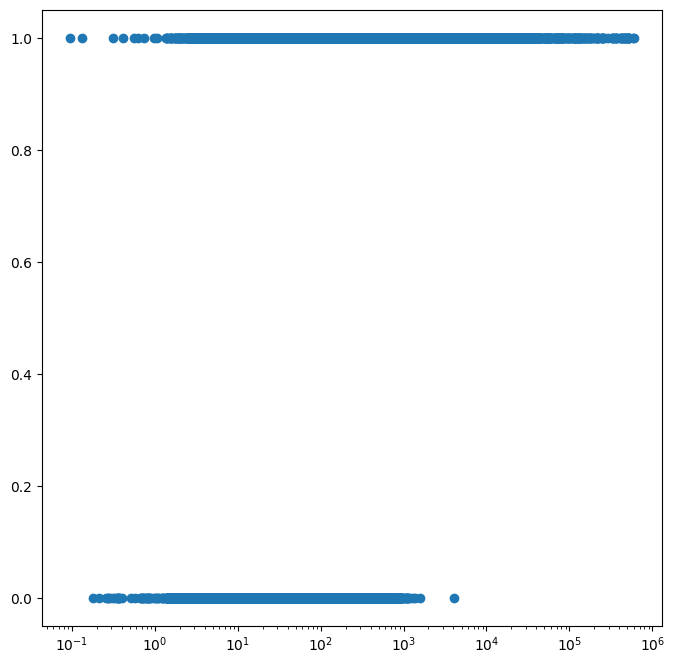

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(grid_pop['pop_wp'], grid_pop['has_builtup'])
ax.set_xscale('log')
plt.show()

# Testing correlation of WorldPop and FB baseline population by weekday
To see if it makes sense to estimate missing baseline data with the WP population

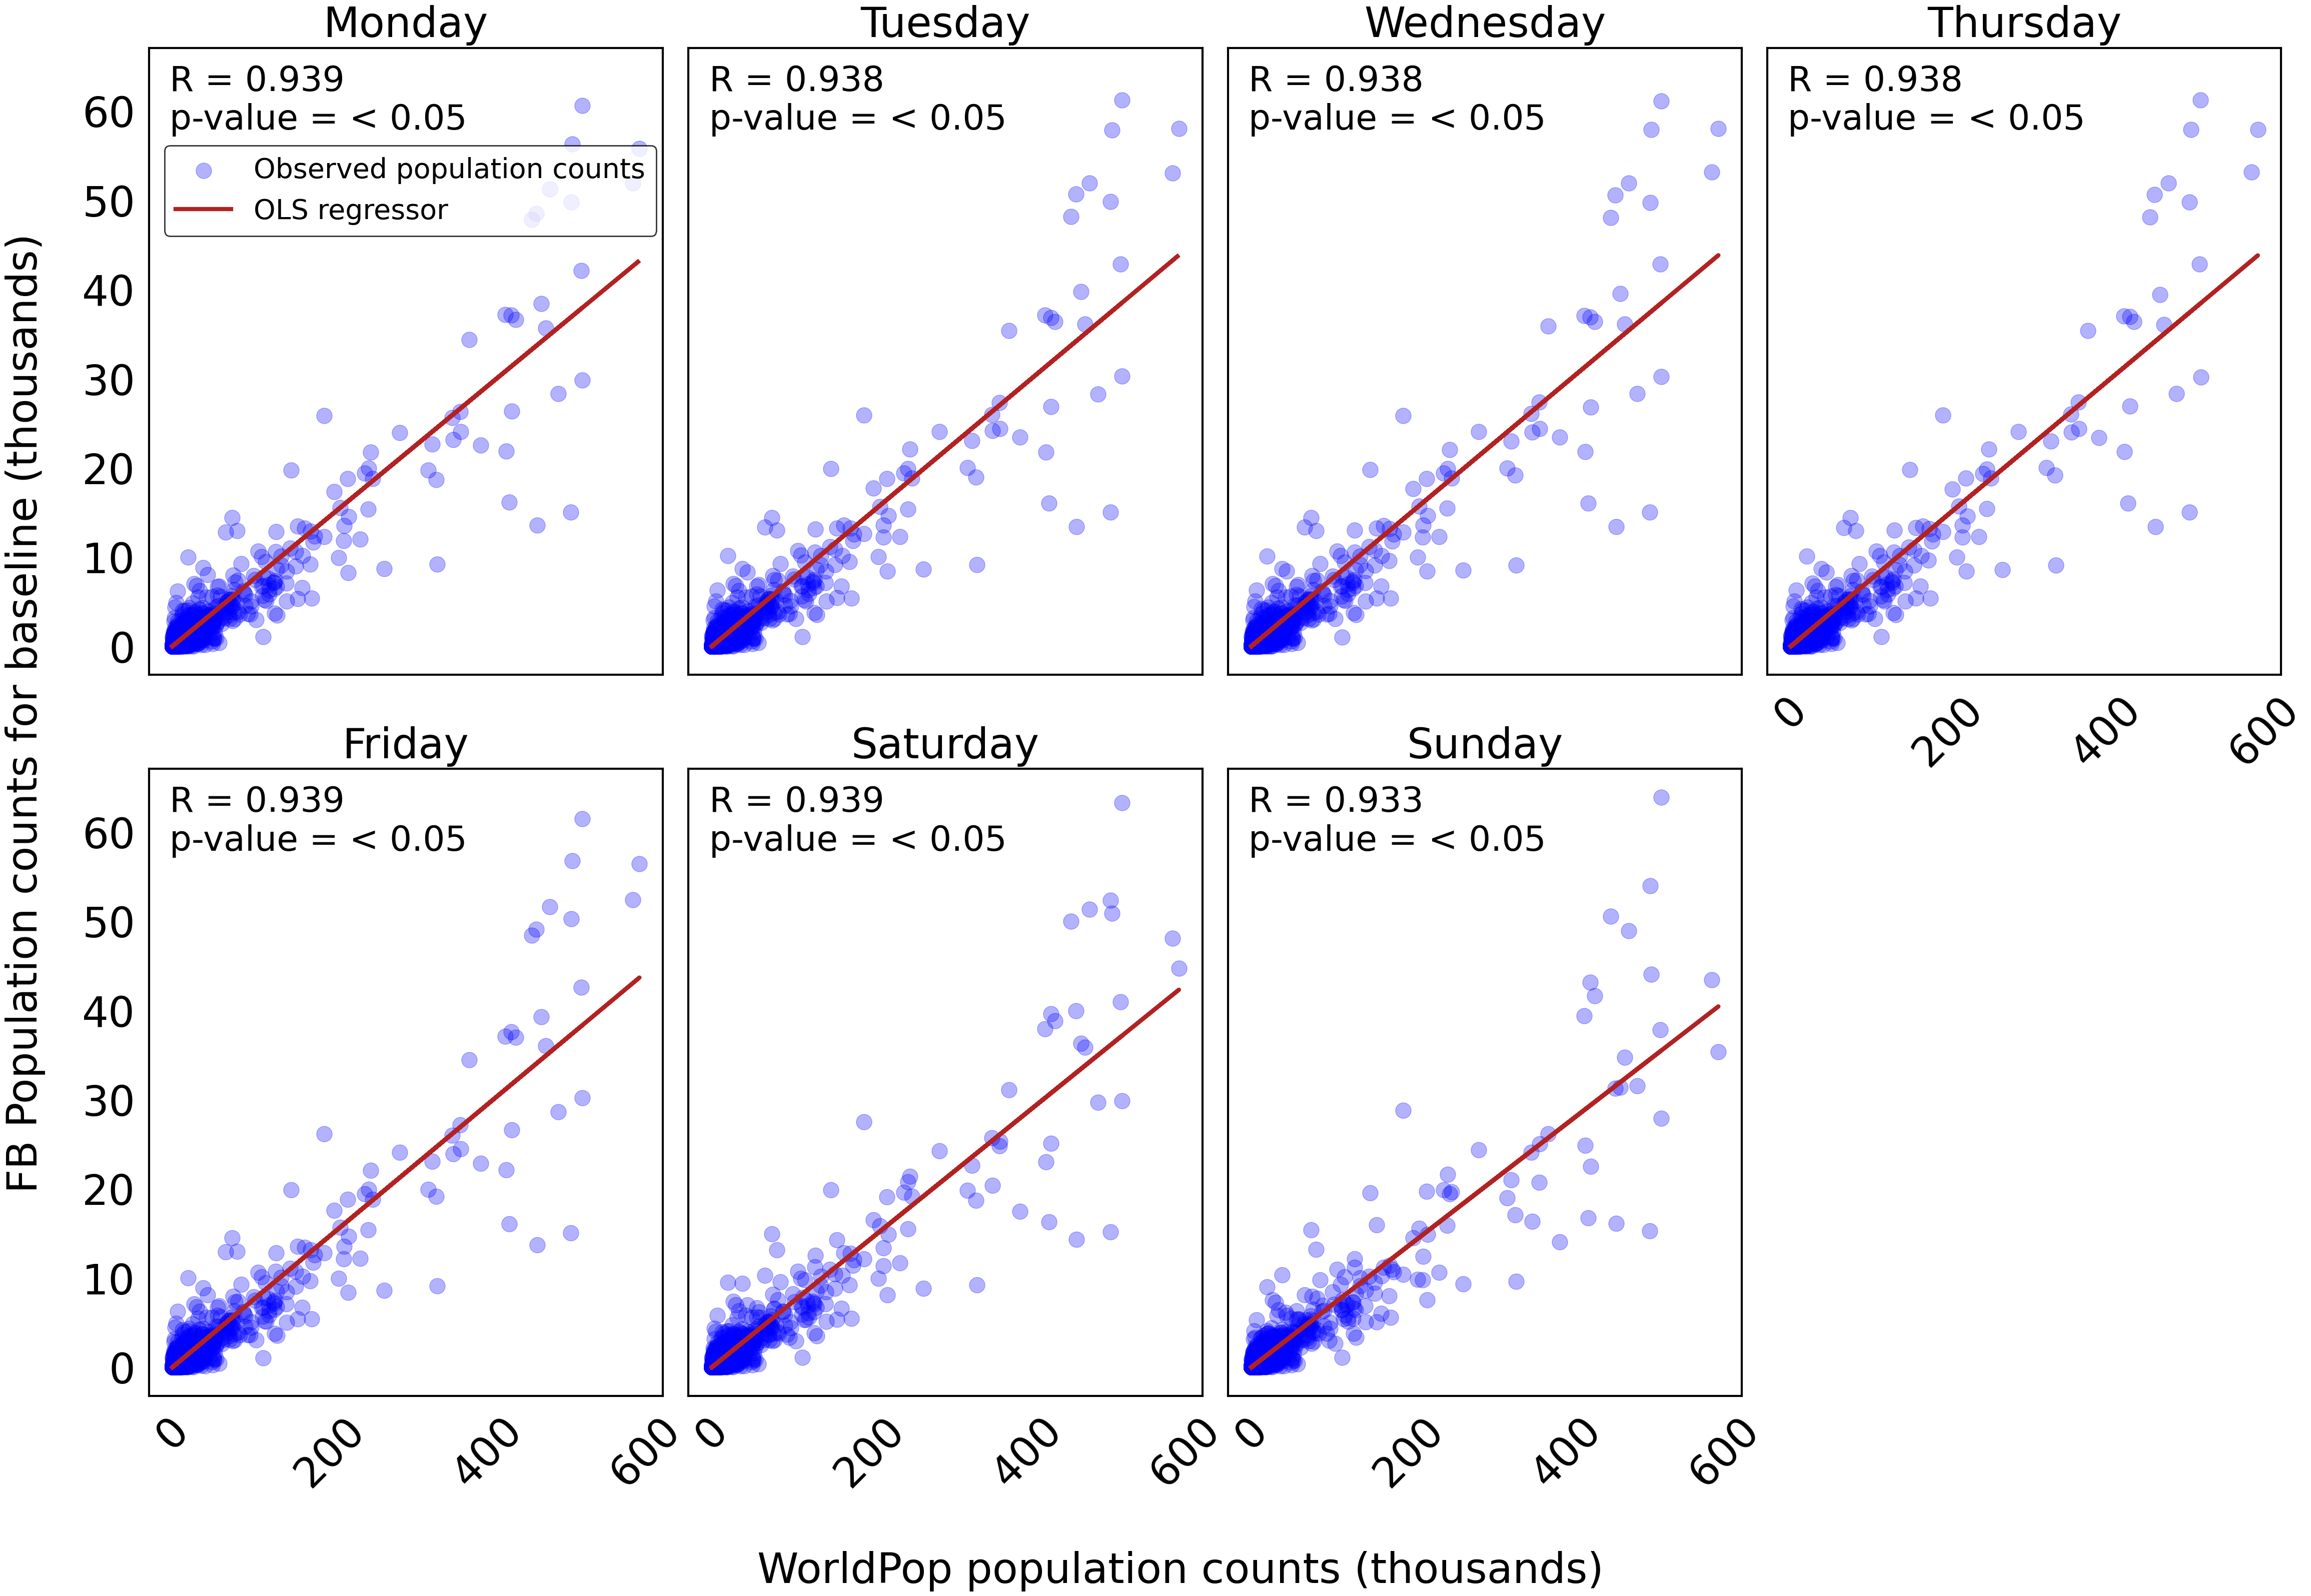

In [12]:
nrows = 2
ncols = 4
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(55, 35))
fig.subplots_adjust(hspace=0.15)
fig.subplots_adjust(wspace=0.05)
ax = axes.flatten()

wday = 0  # use integer for easier control

for i, ax in enumerate(axes.flat):
    if wday > 6:
        # Remove unused subplot for the 8th panel
        fig.delaxes(ax)
        break

    try:
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))

        for spine in ax.spines.values():
            spine.set_linewidth(3)

        grid_pop_plot = grid_pop.copy()
        grid_pop_plot = grid_pop_plot.dropna(subset=['pop_wp']).reset_index(drop=True)
        grid_pop_plot = grid_pop_plot.dropna(subset=[str(wday)]).reset_index(drop=True)
        grid_pop_plot = grid_pop_plot[grid_pop_plot[str(wday)] > 0]
        grid_pop_plot = grid_pop_plot.sort_values(by=['pop_wp']).reset_index(drop=True)

        ax.scatter(
            grid_pop_plot['pop_wp'], grid_pop_plot[str(wday)],
            color='blue', marker="o", label="Observed population counts",
            zorder=2, alpha=0.3, s=500
        )

        xticks = [0]
        upper = 0
        while upper < ax.get_xlim()[1] - 200000:
            upper += 200000
            xticks.append(upper)

        ax.set_xticks(xticks)
        ax.set_xticklabels([int(x / 1000) for x in xticks], rotation=45, color='k')
        yticks = list(ax.get_yticks())
        ax.set_yticks(yticks)
        ax.set_yticklabels([int(y / 1000) for y in yticks], rotation=0, color='k')
        ax.tick_params(axis='both', which='both', width=0, length=0, color='k', labelsize=60, pad=20)

        # Regressions
        grid_pop_dropna = grid_pop.copy().dropna().sort_values(by=['pop_wp'])

        x_predict = grid_pop['pop_wp']

        # OLS regression
        df = pd.DataFrame({'pop_wp': grid_pop_dropna['pop_wp'], 'pop_FB': grid_pop_dropna[str(wday)]})
        res = smf.ols('pop_FB ~ pop_wp - 1', data=df).fit()
        st, data, ss2 = summary_table(res, alpha=0.05)
        y_predict = res.predict(x_predict)
        predict_mean_se = data[:, 3]
        predict_mean_ci_low, predict_mean_ci_upp = data[:, 4:6].T
        predict_ci_low, predict_ci_upp = data[:, 6:8].T

        # Plot OLS regression line
        ax.plot(x_predict, y_predict, color="firebrick", linestyle="-", label="OLS regressor", lw=6, zorder=3)

        # Pearson correlation stats
        pearson = scipy.stats.pearsonr(df['pop_wp'], df['pop_FB'])
        R = f"{pearson.statistic:.3f}"
        pvalue = f"{pearson.pvalue:.2f}"
        if float(pvalue) < 0.05:
            pvalue = '< 0.05'
        ax.text(0.04, 0.87, f'R = {R}\np-value = {pvalue}', transform=ax.transAxes, size=50)

        # Set subplot title by weekday
        weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        ax.set_title(weekdays[wday], size=60, pad=16)

        # Store predictions for imputation if needed
        grid_pop[str(wday) + '_imput'] = y_predict

        wday += 1

    except Exception as e:
        print(f"Plotting stopped due to error: {e}")
        break

legend = axes[0, 0].legend(loc=(0.03, 0.7), fontsize=40)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(2)

# For matplotlib 2.1.1 compatibility
axes[0, 3].xaxis.set_tick_params(which='both', labelbottom=True, labeltop=False)

# Set common axis labels
fig.text(0.5, 0.01, 'WorldPop population counts (thousands)', ha='center', va='center', size=60)
fig.text(0.08, 0.5, 'FB Population counts for baseline (thousands)', ha='center', va='center', rotation='vertical', size=60)

# Uncomment to save the figure
# plt.savefig(wd + f'/plots/correlation-wp-fb-pop-baseline/correlation-wp-fb-pop-baseline-{country_short}.png', bbox_inches='tight')

plt.show()



# Impute missing and invalid population values using model predictions

In [13]:
# Create a copy of grid_pop to perform imputation
grid_pop_imput = grid_pop.copy()

# List of weekday columns as strings
wday_cols = [str(i) for i in range(7)]

# Loop over each row and weekday column to impute missing or invalid values (-1 or NaN)
# If a cell has no built-up pixels, impose zero population as a conservative constraint.
for i in range(len(grid_pop_imput)):
    for col in wday_cols:
        if grid_pop_imput.loc[i, col] == -1 or pd.isna(grid_pop_imput.loc[i, col]):
            if grid_pop_imput.loc[i, 'has_builtup'] == 0:
                grid_pop_imput.loc[i, col] = 0
            else:
                grid_pop_imput.loc[i, col] = grid_pop_imput.loc[i, col + '_imput']

# Drop the '_imput' columns as they are no longer needed
grid_pop_imput = grid_pop_imput.drop(columns=[col + '_imput' for col in wday_cols])

# Save the built-up-constrained imputed grid to file
output_path = wd + f'/data/outputs/{country_short}/grids-with-data/popcell-baseline-imput-pop-builtup/popcell-baseline-imput-pop-builtup.gpkg'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
grid_pop_imput.to_file(output_path)

In [14]:
grid_pop_imput

,FID,geometry,0,1,2,3,4,5,6,pop_wp,has_builtup
0,0,"POLYGON ((-69.96094 -4.21494, -69.96094 -4.216...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0
1,1,"POLYGON ((-69.96094 -4.21494, -69.92853 -4.214...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2,"POLYGON ((-70.00488 -4.17112, -70.00488 -4.191...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,86.369087,0
3,3,"POLYGON ((-70.00488 -4.17112, -69.96094 -4.171...",142.238856,144.273977,144.215812,144.166396,143.715165,139.231750,133.074321,1949.861694,1
4,4,"POLYGON ((-69.96094 -4.21494, -69.96094 -4.171...",976.637078,981.820558,969.339036,972.437329,959.101578,941.713506,927.329020,17733.955078,1
...,...,...,...,...,...,...,...,...,...,...,...
49319,49319,"POLYGON ((-79.73437 15.86627, -79.73682 15.863...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0
49320,49320,"MULTIPOLYGON (((-78.68076 15.83453, -78.68048 ...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0
49321,49321,"POLYGON ((-78.63568 15.85669, -78.63818 15.854...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0
49322,49322,"POLYGON ((-79.72082 15.89630, -79.71942 15.897...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0


# Comparison of original vs. imputed FB population baseline (Monday)

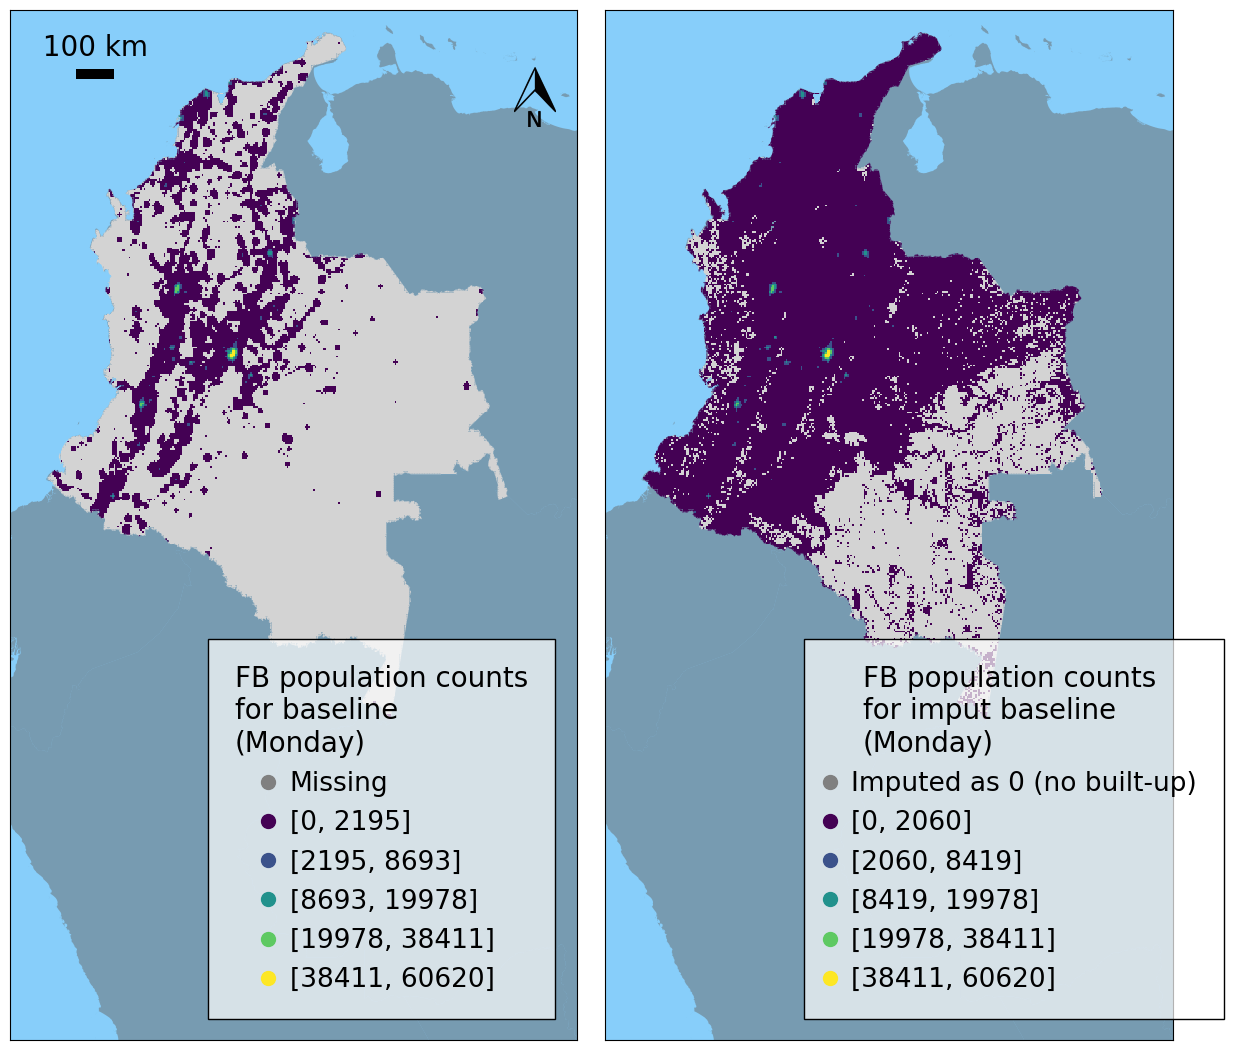

In [15]:
nrows = 1
ncols = 2
fig, (ax1, ax2) = plt.subplots(nrows=nrows, ncols=ncols, sharey=True, figsize=(15, 15))
fig.subplots_adjust(wspace=0.05)

grid_pop_map_positive = grid_pop[grid_pop['0'] > 0].reset_index(drop=True)
grid_pop_map_missing = grid_pop[(grid_pop['0'] == -1) | (pd.isna(grid_pop['0']))].reset_index(drop=True)

grid_pop_imput_map = grid_pop_imput.dropna(subset=['pop_wp']).reset_index(drop=True)
grid_pop_imput_map_positive = grid_pop_imput_map[
    (grid_pop_imput_map['0'] > 0) & (grid_pop_imput_map['has_builtup'] == 1)
].reset_index(drop=True)
grid_pop_imput_forced_zero_map = grid_pop_imput_map[
    grid_pop_imput_map['has_builtup'] == 0
].reset_index(drop=True)

grid_pop_map_positive.plot(
    column='0',
    cmap='viridis',
    scheme='natural_breaks',
    k=5,
    legend=True,
    zorder=2,
    ax=ax1
)
grid_pop_map_missing.plot(color='lightgray', zorder=3, ax=ax1)

grid_pop_imput_map_positive.plot(
    column='0',
    cmap='viridis',
    scheme='natural_breaks',
    k=5,
    legend=True,
    zorder=2,
    ax=ax2
)
grid_pop_imput_forced_zero_map.plot(color='lightgray', zorder=3, ax=ax2)

if country != 'Mexico':
    background = gpd.read_file(wd + '/data/inputs/boundaries/south-america/vc965bq8111.shp').to_crs('EPSG:4326')
else:
    background = gpd.read_file(wd + '/data/inputs/boundaries/central-america/bound_p.shp').to_crs('EPSG:4326')

for ax in (ax1, ax2):
    background.plot(ax=ax, facecolor='dimgray', alpha=0.5, zorder=1)
    ax.set_facecolor('lightskyblue')

    if country == 'Argentina':
        ax.set_xlim(-75, -49)
        ax.set_ylim(-60, -19.5)
    elif country == 'Chile':
        ax.set_xlim(-80, -55)
        ax.set_ylim(-57, -16)
    elif country == 'Colombia':
        ax.set_xlim(-80, -65)
        ax.set_ylim(-12, 13)
    elif country == 'Mexico':
        ax.set_xlim(-119, -75)
        ax.set_ylim(12, 45)

    ax.tick_params(axis='both', which='both', width=0, length=0, color='k', labelleft=False, labelbottom=False)

    labels = [t.get_text() for t in ax.get_legend().get_texts()]

    upper = []
    for i in range(len(labels)):
        a = labels[i].split(',')[1]
        b = [e for e in a if e.isdigit() or e == '.']
        upper.append(float(''.join(b)))
    upper[-1] += 0.005

    if ax == ax1:
        first_label = 'Missing'
    else:
        first_label = 'Imputed as 0 (no built-up)'

    custom_labels = [first_label]
    custom_labels.append('[0, ' + str(int(upper[0])) + ']')
    for i in range(len(upper) - 1):
        custom_labels.append('[' + str(int(upper[i])) + ', ' + str(int(upper[i + 1])) + ']')

    colors = ['gray'] + mcp.gen_color(cmap='viridis', n=5)
    legend_elements = [
        Line2D([0], [0], lw=0, color=colors[i], marker='o', markersize=10, label=custom_labels[i])
        for i in range(len(colors))
    ]

    if ax == ax2:
        title = "FB population counts \nfor imput baseline \n(Monday)"
    else:
        title = 'FB population counts\nfor baseline \n(Monday)'

    if country == 'Argentina':
        loc = (0.37, 0.01)
    elif country == 'Chile':
        loc = (0.37, 0.02)
    elif country == 'Colombia':
        loc = (0.35, 0.02)
    elif country == 'Mexico':
        loc = (0.52, 0.33)

    legend = ax.legend(
        handles=legend_elements,
        handlelength=0,
        fontsize=19,
        shadow=False,
        fancybox=False,
        loc=loc,
        ncol=1,
        columnspacing=0.1,
        borderpad=1,
        title=title,
    )
    for t in legend.get_texts():
        t.set_ha('right')
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_linewidth(1)
    legend.get_frame().set_alpha(None)
    legend.get_frame().set_facecolor((1, 1, 1, 0.7))
    legend.get_title().set_fontsize('20')

    if ax == ax1:
        ax.add_artist(
            ScaleBar(
                dx=1,
                units="km",
                dimension="si-length",
                length_fraction=0.1,
                scale_formatter=lambda value, unit: f' {value * 100} km ',
                pad=0.7,
                sep=5,
                border_pad=1,
                scale_loc='top',
                box_color='w',
                box_alpha=0,
                font_properties={'size': 20},
                location='upper left',
            )
        )

    im = plt.imread(wd + '/data/inputs/boundaries/north-arrow.png')

    if country == 'Argentina':
        loc_arr1 = [0.455, 0.75, 0.04, 0.04]
        loc_arr2 = [0.855, 0.75, 0.04, 0.04]
    elif country == 'Chile':
        loc_arr1 = [0.455, 0.77, 0.04, 0.04]
        loc_arr2 = [0.855, 0.77, 0.04, 0.04]
    elif country == 'Colombia':
        loc_arr1 = [0.455, 0.76, 0.04, 0.04]
        loc_arr2 = [0.855, 0.61, 0.04, 0.04]
    elif country == 'Mexico':
        loc_arr1 = [0.16, 0.58, 0.04, 0.04]
        loc_arr2 = [0.56, 0.58, 0.04, 0.04]

    newax = fig.add_axes(loc_arr1, zorder=1)
    newax.tick_params(axis='both', which='both', labelbottom=False, labelleft=False, width=0, length=0)
    newax.set_facecolor('None')
    plt.setp(newax.spines.values(), linewidth=0)
    newax.imshow(im)

# Uncomment if you want to add a second north-arrow
# newax = fig.add_axes(loc_arr2, zorder=1)
# newax.tick_params(axis='both', which='both', labelbottom=False, labelleft=False, width=0, length=0)
# newax.set_facecolor('None')
# plt.setp(newax.spines.values(), linewidth=0)
# newax.imshow(im)

# plt.savefig(wd + '/plots/map-missing-fb-pop-baseline/map-missing-fb-pop-baseline-' + country_short + '.pdf', bbox_inches='tight')

plt.show()
